# USA Housing

Năm cột số dùng để đoán:

- Avg. Area Income là thu nhập trung bình của khu vực
- Avg. Area House Age là tuổi nhà trung bình
- Avg. Area Number of Rooms là số phòng trung bình
- Avg. Area Number of Bedrooms là số phòng ngủ trung bình
- Area Population là dân số khu vực

Address là địa chỉ chữ. Cột này không đưa vào mô hình.


## 1. Đọc dữ liệu


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("../data/USA_Housing.csv")
df.head()


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


## 2. Xem tổng quan

describe cho trung bình, giá trị nhỏ nhất và lớn nhất của các cột số. Giá trung bình khoảng 1,232,073.

columns in đủ 7 tên cột, kể cả Address.


In [17]:
df.describe(include='all')
# df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000
unique,NaN,NaN,NaN,NaN,NaN,NaN,5000
top,NaN,NaN,NaN,NaN,NaN,NaN,"9454 Kelly Light Suite 194\nEast Gina, KY 49894"
freq,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06,NaN
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05,NaN
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04,NaN
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700,9.975771e+05,NaN
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690,1.232669e+06,NaN
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770,1.471210e+06,NaN


In [22]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

## 3. Bỏ cột địa chỉ

Address là chữ, mỗi căn một địa chỉ khác nhau. Linear Regression cần cột số. Bỏ Address trước khi tách feature.


In [27]:
# df = df.drop(columns='Address')
df.head()


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


## 4. Thu nhập khu vực và giá

Biểu đồ này đặt Avg. Area Income trên trục ngang và Price trên trục dọc. Khu có thu nhập cao hơn thường có giá nhà cao hơn. Đám điểm đi theo một hướng, chưa thành một đường thẳng duy nhất vì giá còn phụ thuộc tuổi nhà, số phòng và dân số.


<AxesSubplot:xlabel='Avg. Area Income', ylabel='Price'>

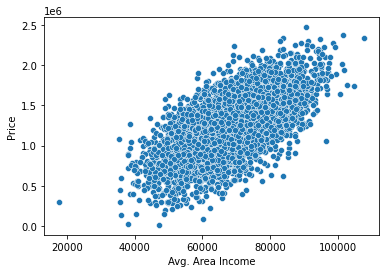

In [4]:
sns.scatterplot(x=df['Avg. Area Income'], y = df['Price'])

## 5. Tách feature, label, rồi chia tập



In [9]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(5000, 5)


## 6. Training

$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + w_4 x_4 + w_5 x_5 + b$$

Năm weight nằm trong coef_. b là intercept_.


In [10]:
model = LinearRegression()
model.fit(X_train, y_train)
model

LinearRegression()

In [11]:
# y_pred = ?
# mse = ?
# r2 = ?
# rmse = ?
# print("MSE =", f"{mse:,.0f}")
# print("RMSE =", f"{rmse:,.0f}")
# print("R2 =", round(r2, 3))


## 8. Một căn trong tập kiểm tra

Căn đầu tiên của tập kiểm tra không nằm trong tập học. In giá thật cạnh giá đoán. Hai số có dấu phẩy để dễ đọc.

Nếu giá đoán gần giá thật và khoảng lệch nhỏ hơn RMSE, căn đó nằm trong mức sai số trung bình của mô hình.


In [12]:
can = X_test.iloc[[0]]
# gia_that = ?
# gia_doan = ?
# print(can)
# print("Real price =", f"{gia_that:,.0f}")
# print("Predicted price =", f"{gia_doan:,.0f}")


## 9. Save model

joblib.dump ghi weight và bias ra USA_Housing.pkl. joblib.load đọc lại khi cần đoán, không cần fit lại.

Khu thử dùng năm số tròn để dễ nhìn: thu nhập 70,000, tuổi nhà 6, 7 phòng, 4 phòng ngủ, dân số 40,000.
